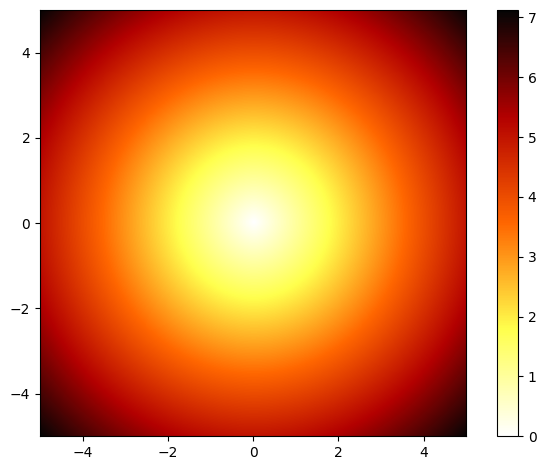

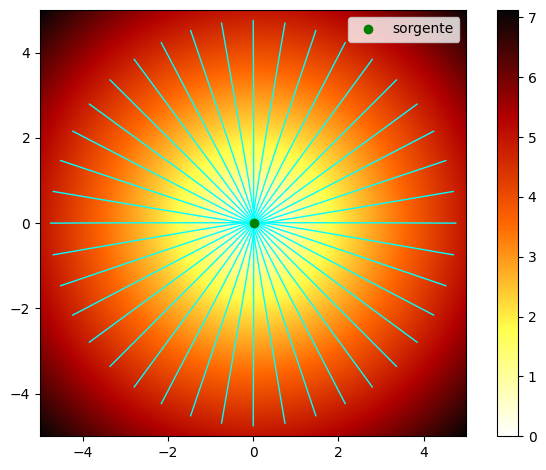

In [ ]:
# ==============================================================================
# ----------- VERSIONE FIM PARALLELIZZATA CON CUPY DI FASCIO IN SPAZIO LIBERO---
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import cupy as cp

from typing import Text
from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive
from scipy.ndimage import distance_transform_edt

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx, ny   = 500, 500
nRows, nCols = 500, 500
sidex, sidey = 5, 5
domain = [-sidex, sidex, -sidey, sidey]
x  = np.linspace(domain[0], domain[1], nx)
y  = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)
eps = 1e-6
h = dx

#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------

F = np.ones(X.shape)

# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO ON CUPY
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

ix0, iy0 = 250, 250
T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0.0

active = np.zeros(T.shape, dtype=bool)
for dr, dc in [(0,-1),(0,1),(-1,0),(1,0)]:
    nr, nc = iy0 + dr, ix0 + dc
    if 0 <= nr < nRows and 0 <= nc < nCols:
        active[nr, nc] = True


#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu      = cp.array(T)
F_gpu      = cp.array(F)
active_gpu = cp.array(active)


#------------------ GODUNOV 1 --------------------------------------------------

def Godunov_update(T, F, row, col):
    left  = cp.where(col - 1 >= 0,     T[row, cp.clip(col-1, 0, nCols-1)], cp.inf)
    right = cp.where(col + 1 < nCols,  T[row, cp.clip(col+1, 0, nCols-1)], cp.inf)
    down  = cp.where(row - 1 >= 0,     T[cp.clip(row-1, 0, nRows-1), col], cp.inf)
    up    = cp.where(row + 1 < nRows,  T[cp.clip(row+1, 0, nRows-1), col], cp.inf)

    Txmin = cp.minimum(left, right)
    Tymin = cp.minimum(down, up)

    a = cp.minimum(Txmin, Tymin)
    b = cp.maximum(Txmin, Tymin)

    f   = F[row, col]
    rhs = h / f

    cond   = (b - a) < rhs
    disc   = cp.maximum(2 * rhs**2 - (a - b)**2, 0)
    u_quad = (a + b + cp.sqrt(disc)) / 2
    u_lin  = a + rhs

    return cp.where(cond, u_quad, u_lin)


#------------------  AGGIORNAMENTO FIM  ----------------------------------------
def FIM(T, F, active):

    while cp.any(active):

        row, col = cp.where(active)
        p = T[row, col]
        q = Godunov_update(T, F, row, col)

        T[row, col] = q

        converged_cond = cp.abs(p - q) < eps
        conv_row, conv_col = row[converged_cond], col[converged_cond]
        active[conv_row, conv_col] = False

        # ── propagazione ai vicini: vettorizzata con shift ────────────────────
        # invece del loop Python for r,c in [...], costruisco tutti e 4
        # i batch di vicini come array e li processo in un colpo solo

        all_nb_row = cp.concatenate([conv_row-1, conv_row+1,
                                     conv_row,   conv_row  ])
        all_nb_col = cp.concatenate([conv_col,   conv_col,
                                     conv_col-1, conv_col+1])

        # filtro: dentro griglia
        valid = ((all_nb_row >= 0) & (all_nb_row < nRows) &
                 (all_nb_col >= 0) & (all_nb_col < nCols))
        nb_row = all_nb_row[valid]
        nb_col = all_nb_col[valid]

        if nb_row.size == 0:
            continue

        # filtro: non muri
        not_wall = ~cp.isinf(F[nb_row, nb_col])
        nb_row = nb_row[not_wall]
        nb_col = nb_col[not_wall]

        if nb_row.size == 0:
            continue

        # aggiorna solo se migliora T
        p2 = T[nb_row, nb_col]
        q2 = Godunov_update(T, F, nb_row, nb_col)

        improve = q2 < p2
        nb_row, nb_col, q2 = nb_row[improve], nb_col[improve], q2[improve]

        T[nb_row, nb_col]      = q2
        active[nb_row, nb_col] = True

    return T


#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------
T_final_gpu = FIM(T_gpu, F_gpu, active_gpu)

# torna su CPU solo per il plot
T_final = cp.asnumpy(T_final_gpu)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_fim_gpu.npz', T_ref = T_final)
"""

#------------------  STAMPA DEI RISULTATI --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()


# ==============================================================================
# CALCOLO DEI RAGGI (INTERP.BILINEARE + RK4)
# ==============================================================================
from scipy.ndimage import distance_transform_edt

#------------------  GRADIENTE + RIEMPIMENTO MURI ------------------------------

#------------------  GRADIENTE + RIEMPIMENTO MURI (TUTTO SU GPU) ---------------

def Gradient_FD_gpu(T_gpu, F_gpu, dx, dy):
    wall_mask = cp.isinf(F_gpu)
    nRows, nCols = T_gpu.shape

    Tx = cp.zeros_like(T_gpu)
    Ty = cp.zeros_like(T_gpu)

    valid = ~wall_mask

    left_ok  = cp.zeros_like(valid)
    right_ok = cp.zeros_like(valid)
    left_ok[:, 1:]  = valid[:, :-1]
    right_ok[:, :-1] = valid[:, 1:]

    T_left  = cp.full_like(T_gpu, cp.nan)
    T_right = cp.full_like(T_gpu, cp.nan)
    T_left[:, 1:]  = T_gpu[:, :-1]
    T_right[:, :-1] = T_gpu[:, 1:]

    both_x = left_ok & right_ok
    only_left_x  = left_ok & ~right_ok
    only_right_x = right_ok & ~left_ok

    Tx[both_x] = (T_right[both_x] - T_left[both_x]) / (2 * dx)
    Tx[only_right_x] = (T_right[only_right_x] - T_gpu[only_right_x]) / dx
    Tx[only_left_x]  = (T_gpu[only_left_x] - T_left[only_left_x]) / dx

    down_ok = cp.zeros_like(valid)
    up_ok   = cp.zeros_like(valid)
    down_ok[1:, :] = valid[:-1, :]
    up_ok[:-1, :]  = valid[1:, :]

    T_down = cp.full_like(T_gpu, cp.nan)
    T_up   = cp.full_like(T_gpu, cp.nan)
    T_down[1:, :] = T_gpu[:-1, :]
    T_up[:-1, :]  = T_gpu[1:, :]

    both_y = down_ok & up_ok
    only_down_y = down_ok & ~up_ok
    only_up_y   = up_ok & ~down_ok

    Ty[both_y] = (T_up[both_y] - T_down[both_y]) / (2 * dy)
    Ty[only_up_y]   = (T_up[only_up_y] - T_gpu[only_up_y]) / dy
    Ty[only_down_y] = (T_gpu[only_down_y] - T_down[only_down_y]) / dy

    grad_norm = cp.sqrt(Tx**2 + Ty**2)
    scale = cp.zeros_like(grad_norm)
    finite_F = cp.isfinite(F_gpu) & (grad_norm > 1e-12)
    scale[finite_F] = 1.0 / (F_gpu[finite_F] * grad_norm[finite_F])

    Tx = cp.where(finite_F, Tx * scale, 0.0)
    Ty = cp.where(finite_F, Ty * scale, 0.0)

    Tx[wall_mask] = 0.0
    Ty[wall_mask] = 0.0

    return Tx, Ty, wall_mask


def fill_wall_nans_gpu(field_gpu, wall_mask_gpu):
    """
    distance_transform_edt non esiste in cupyx.scipy.ndimage in tutte le versioni
    con return_indices, quindi lo calcoliamo su CPU (costo trascurabile:
    è un'operazione O(n) fatta una sola volta, non nel loop dei raggi)
    e poi ricarichiamo il risultato su GPU.
    """
    wall_mask_cpu = cp.asnumpy(wall_mask_gpu)
    field_cpu = cp.asnumpy(field_gpu)
    idx = distance_transform_edt(wall_mask_cpu, return_distances=False, return_indices=True)
    filled_cpu = field_cpu[tuple(idx)]
    return cp.array(filled_cpu)


#------------------  CALCOLO SU GPU ---------------------------------------------

Tx_g, Ty_g, wall_mask_gpu = Gradient_FD_gpu(T_final_gpu, F_gpu, dx, dy)
Tx_filled = fill_wall_nans_gpu(Tx_g, wall_mask_gpu)
Ty_filled = fill_wall_nans_gpu(Ty_g, wall_mask_gpu)

x_gpu = cp.array(x)
y_gpu = cp.array(y)

#------------------  UPLOAD GRADIENTI SU GPU -----------------------------------

Tx_gpu = cp.array(Tx_filled)
Ty_gpu = cp.array(Ty_filled)
x_gpu  = cp.array(x)
y_gpu  = cp.array(y)

#------------------ INTERPOLAZIONE BILINEARE VETTORIALE (GPU) ------------------

def bilinear_interp_gpu(px, py, field_gpu, x_gpu, y_gpu, dx, dy, nCols, nRows):
    """px, py: array cupy (n_rays,) di coordinate. Ritorna field interpolato in ogni punto."""
    fx = (px - x_gpu[0]) / dx
    fy = (py - y_gpu[0]) / dy

    ix0 = cp.clip(cp.floor(fx).astype(cp.int32), 0, nCols - 2)
    iy0 = cp.clip(cp.floor(fy).astype(cp.int32), 0, nRows - 2)
    tx  = cp.clip(fx - ix0, 0.0, 1.0)
    ty  = cp.clip(fy - iy0, 0.0, 1.0)

    f00 = field_gpu[iy0,     ix0]
    f10 = field_gpu[iy0,     ix0 + 1]
    f01 = field_gpu[iy0 + 1, ix0]
    f11 = field_gpu[iy0 + 1, ix0 + 1]

    return (f00 * (1 - tx) * (1 - ty) +
            f10 * tx       * (1 - ty) +
            f01 * (1 - tx) * ty +
            f11 * tx       * ty)


def grad_at_batch(px, py, Tx_gpu, Ty_gpu, x_gpu, y_gpu, dx, dy, nCols, nRows):
    # clamp ai bordi del dominio (equivalente al fill_value=None/extrapolazione bordo)
    px_c = cp.clip(px, x_gpu[0], x_gpu[-1])
    py_c = cp.clip(py, y_gpu[0], y_gpu[-1])

    gx = bilinear_interp_gpu(px_c, py_c, Tx_gpu, x_gpu, y_gpu, dx, dy, nCols, nRows)
    gy = bilinear_interp_gpu(px_c, py_c, Ty_gpu, x_gpu, y_gpu, dx, dy, nCols, nRows)

    invalid = ~(cp.isfinite(gx) & cp.isfinite(gy))
    gx = cp.where(invalid, 0.0, gx)
    gy = cp.where(invalid, 0.0, gy)
    return gx, gy


#------------------ RK4 VETTORIZZATO SU TUTTI I RAGGI (GPU) --------------------

def trace_rays_rk4_batch_gpu(start_pts, source_pt, Tx_gpu, Ty_gpu,
                              x_gpu, y_gpu, dx, dy, ds, max_steps,
                              nCols, nRows):

    n_rays = start_pts.shape[0]
    px = cp.array(start_pts[:, 0])
    py = cp.array(start_pts[:, 1])
    sx, sy = source_pt

    active = cp.ones(n_rays, dtype=bool)   # "corsie" ancora in moto
    traj = [cp.stack([px, py], axis=1)]

    for step in range(max_steps):

        if not cp.any(active):
            break

        # ---- k1,k2,k3,k4: ognuno è un vettore (n_rays,), calcolato per TUTTI i raggi insieme ----
        k1x, k1y = grad_at_batch(px, py, Tx_gpu, Ty_gpu, x_gpu, y_gpu, dx, dy, nCols, nRows)
        k1x, k1y = -k1x, -k1y

        k2x, k2y = grad_at_batch(px + 0.5*ds*k1x, py + 0.5*ds*k1y,
                                  Tx_gpu, Ty_gpu, x_gpu, y_gpu, dx, dy, nCols, nRows)
        k2x, k2y = -k2x, -k2y

        k3x, k3y = grad_at_batch(px + 0.5*ds*k2x, py + 0.5*ds*k2y,
                                  Tx_gpu, Ty_gpu, x_gpu, y_gpu, dx, dy, nCols, nRows)
        k3x, k3y = -k3x, -k3y

        k4x, k4y = grad_at_batch(px + ds*k3x, py + ds*k3y,
                                  Tx_gpu, Ty_gpu, x_gpu, y_gpu, dx, dy, nCols, nRows)
        k4x, k4y = -k4x, -k4y

        dpx = (k1x + 2*k2x + 2*k3x + k4x) / 6.0
        dpy = (k1y + 2*k2y + 2*k3y + k4y) / 6.0

        speed = cp.sqrt(dpx**2 + dpy**2)
        stalled = speed < 1e-12   # equivalente a norm(k1) < 1e-12

        px_new = cp.where(active, px + ds*dpx, px)
        py_new = cp.where(active, py + ds*dpy, py)

        dist_to_source = cp.sqrt((px_new - sx)**2 + (py_new - sy)**2)
        reached = dist_to_source < ds

        disp = cp.sqrt((px_new - px)**2 + (py_new - py)**2)
        stuck = disp < 1e-8   # criterio di stagnazione, come nel codice sequenziale

        active = active & ~(reached | stalled | stuck)

        px, py = px_new, py_new
        traj.append(cp.stack([px, py], axis=1))

    traj_gpu = cp.stack(traj, axis=0)      # shape (n_steps, n_rays, 2)
    return cp.asnumpy(traj_gpu)


#------------------  LANCIO DEL FASCIO -------------------------------------------

n_rays = 40
R_exit = sidex * 0.95
angles = np.linspace(0, 2*np.pi, n_rays, endpoint=False)

start_pts = np.stack([R_exit*np.cos(angles), R_exit*np.sin(angles)], axis=1)
source_pt = (x[ix0], y[iy0])

ds = dx/2
max_steps = 10000
nCols, nRows = X.shape[1], X.shape[0]

traj = trace_rays_rk4_batch_gpu(start_pts, source_pt, Tx_gpu, Ty_gpu,
                                 x_gpu, y_gpu, dx, dy, ds, max_steps,
                                 nCols, nRows)

# traj shape: (n_steps+1, n_rays, 2) -> ricostruisco lista di raggi per il plot
rays_fan = [traj[:, i, :] for i in range(n_rays)]

#------------------  PLOT (identico a prima) --------------------------------------

fig, ax = plt.subplots()
im = ax.imshow(T_final, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal', cmap=cmap2)
plt.colorbar(im, ax=ax)
for ray in rays_fan:
    ax.plot(ray[:, 0], ray[:, 1], color='cyan', linewidth=1)
ax.plot(*source_pt, 'go', label='sorgente')
ax.legend()
plt.tight_layout()
plt.show()